#### 多板块指数跟随性时间序列分析模型比较

1. 数据准备与预处理

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns 
from datetime import datetime, timedelta
import warnings 
warnings.filterwarnings('ignore') 
 
# 设置中文字体 
plt.rcParams['font.sans-serif']  = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus']  = False 


In [2]:
def generate_a_sector_data():
    """生成模拟的A股板块指数数据"""
    np.random.seed(42) 
    
    # 生成日期范围（3年数据）
    dates = pd.date_range('2020-01-01',  '2023-12-31', freq='D')
    n_obs = len(dates)
    
    # 基础市场因子（模拟大盘）
    t = np.linspace(0,  10*np.pi,  n_obs)
    market_factor = 1000 + 200 * np.sin(t)  + 50 * np.random.randn(n_obs) 
    
    # 生成各板块指数（具有不同的跟随特性）
    sectors = {
        '金融板块': {
            'base': 0.8,  # 对大盘的跟随程度 
            'lag': 0,     # 滞后阶数
            'volatility': 0.02
        },
        '科技板块': {
            'base': 1.2,  # 高弹性 
            'lag': -1,    # 领先大盘 
            'volatility': 0.03
        },
        '消费板块': {
            'base': 0.9,  # 中等跟随 
            'lag': 1,     # 滞后大盘
            'volatility': 0.025
        },
        '医药板块': {
            'base': 0.7,  # 低相关性 
            'lag': 2,     # 明显滞后
            'volatility': 0.028 
        },
        '周期板块': {
            'base': 1.1,  # 高弹性
            'lag': -2,    # 明显领先 
            'volatility': 0.035
        }
    }
    
    # 生成板块数据
    sector_data = {}
    sector_data['大盘指数'] = market_factor
    
    for sector, params in sectors.items(): 
        base_value = 1000
        lag = params['lag']
        base_corr = params['base'] 
        vol = params['volatility']
        
        if lag < 0:
            # 领先大盘 
            shifted_market = np.roll(market_factor,  lag)
            shifted_market[:abs(lag)] = market_factor[:abs(lag)]
        elif lag > 0:
            # 滞后大盘 
            shifted_market = np.roll(market_factor,  -lag)
            shifted_market[-lag:] = market_factor[-lag:]
        else:
            shifted_market = market_factor
        
        sector_price = base_value + base_corr * (shifted_market - 1000) + \
                      vol * base_value * np.random.randn(n_obs) 
        
        sector_data[sector] = sector_price
    
    df = pd.DataFrame(sector_data, index=dates)
    
    # 添加收益率数据 
    returns_df = df.pct_change().dropna() 
    
    return df, returns_df 

In [3]:
# 生成数据
price_df, returns_df = generate_a_sector_data()

2. 基础相关性分析

In [4]:
def basic_correlation_analysis(price_df, returns_df):
    """基础相关性分析"""
    
    fig, axes = plt.subplots(2,  2, figsize=(16, 12))
    
    # 1. 价格走势图
    normalized_prices = price_df / price_df.iloc[0]  * 100  # 标准化为100起点 
    for column in normalized_prices.columns: 
        axes[0, 0].plot(normalized_prices.index,  normalized_prices[column], 
                       label=column, linewidth=1.5, alpha=0.8)
    axes[0, 0].set_title('A股各板块指数走势（标准化）')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 收益率相关性热图
    correlation_matrix = returns_df.corr() 
    sns.heatmap(correlation_matrix,  annot=True, cmap='coolwarm', 
                center=0, ax=axes[0, 1], fmt='.3f')
    axes[0, 1].set_title('板块收益率相关性矩阵')
    
    # 3. 滚动相关性（60日窗口）
    rolling_corr = returns_df['科技板块'].rolling(window=60).corr(returns_df['大盘指数'])
    axes[1, 0].plot(rolling_corr.index,  rolling_corr, linewidth=1.5)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 0].set_title('科技板块与大盘的60日滚动相关性')
    axes[1, 0].set_ylabel('相关系数')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. 收益率分布
    returns_df[['金融板块', '科技板块', '消费板块']].hist(
        bins=50, alpha=0.7, ax=axes[1, 1]
    )
    axes[1, 1].set_title('主要板块收益率分布')
    
    plt.tight_layout() 
    plt.show() 
    
    return correlation_matrix

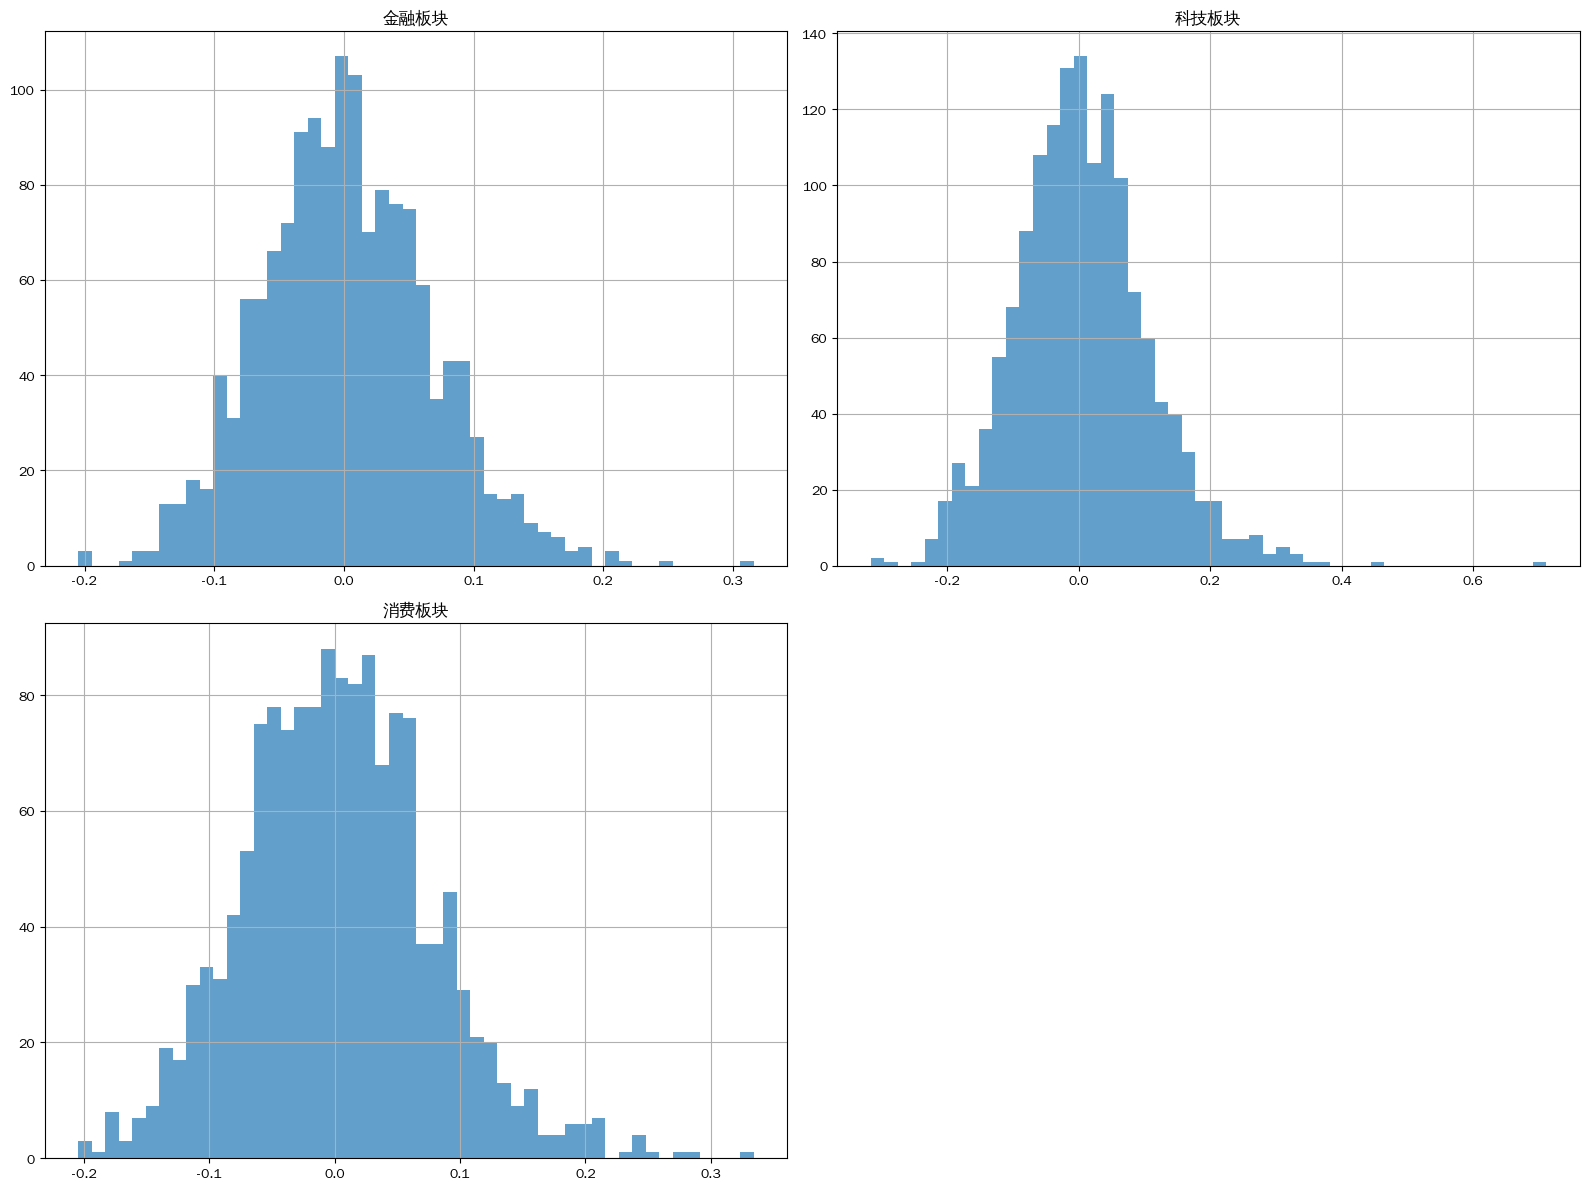

In [5]:
# 基础分析 
corr_matrix = basic_correlation_analysis(price_df, returns_df)

3. 模型比较框架

In [6]:
from statsmodels.tsa.api  import VAR 
from statsmodels.tsa.vector_ar.vecm  import VECM
from sklearn.metrics  import mean_squared_error, mean_absolute_error
from dtaidistance import dtw
from scipy import stats 
import torch 
import torch.nn  as nn

In [7]:
class FollowingAnalysisModels:
    """多模型跟随性分析比较框架"""
    
    def __init__(self, returns_df):
        self.returns_df  = returns_df
        self.models  = {}
        self.results  = {}
        
    def cross_correlation_analysis(self, max_lag=10):
        """交叉相关分析"""
        print("=" * 50)
        print("1. 交叉相关分析")
        print("=" * 50)
        
        sectors = self.returns_df.columns  
        n_sectors = len(sectors)
        
        lead_lag_matrix = np.zeros((n_sectors,  n_sectors))
        max_corr_matrix = np.zeros((n_sectors,  n_sectors))
        
        for i, sector1 in enumerate(sectors):
            for j, sector2 in enumerate(sectors):
                if i != j:
                    ts1 = self.returns_df[sector1].values 
                    ts2 = self.returns_df[sector2].values 
                    
                    # 计算交叉相关
                    correlations = []
                    for lag in range(-max_lag, max_lag + 1):
                        if lag < 0:
                            corr = np.corrcoef(ts1[-lag:],  ts2[:lag])[0, 1]
                        elif lag > 0:
                            corr = np.corrcoef(ts1[:-lag],  ts2[lag:])[0, 1]
                        else:
                            corr = np.corrcoef(ts1,  ts2)[0, 1]
                        correlations.append(corr) 
                    
                    best_lag = np.argmax(np.abs(correlations))  - max_lag
                    max_corr = correlations[best_lag + max_lag]
                    
                    lead_lag_matrix[i, j] = best_lag 
                    max_corr_matrix[i, j] = max_corr 
        
        # 创建结果DataFrame 
        lead_lag_df = pd.DataFrame(lead_lag_matrix, 
                                  index=sectors, columns=sectors)
        max_corr_df = pd.DataFrame(max_corr_matrix,
                                  index=sectors, columns=sectors)
        
        self.results['cross_correlation']  = {
            'lead_lag': lead_lag_df,
            'max_correlation': max_corr_df 
        }
        
        print("领先-滞后关系矩阵:")
        print(lead_lag_df)
        print("\n最大相关系数矩阵:")
        print(max_corr_df.round(3)) 
        
        return lead_lag_df, max_corr_df 
    
    def var_analysis(self, max_lags=10):
        """VAR模型分析"""
        print("\n" + "=" * 50)
        print("2. VAR模型分析")
        print("=" * 50)
        
        try:
            # 拟合VAR模型 
            model = VAR(self.returns_df) 
            lag_results = model.select_order(maxlags=max_lags) 
            optimal_lags = lag_results.aic  
            
            var_model = model.fit(optimal_lags) 
            
            # 格兰杰因果关系
            causality_results = {}
            sectors = self.returns_df.columns  
            
            for cause in sectors:
                for effect in sectors:
                    if cause != effect:
                        test_result = var_model.test_causality( 
                            effect, cause, kind='f'
                        )
                        causality_results[(cause, effect)] = test_result.pvalue 
            
            # 脉冲响应分析 
            irf = var_model.irf(10) 
            
            self.results['var']  = {
                'model': var_model,
                'optimal_lags': optimal_lags,
                'causality': causality_results,
                'irf': irf 
            }
            
            print(f"最优滞后阶数: {optimal_lags}")
            print("\n格兰杰因果关系 (p值):")
            for (cause, effect), pval in causality_results.items(): 
                if pval < 0.05:
                    print(f"  {cause} → {effect}: {pval:.4f} ***")
            
            return var_model
            
        except Exception as e:
            print(f"VAR分析错误: {e}")
            return None
    
    def vecm_analysis(self):
        """VECM协整分析（适用于非平稳序列）"""
        print("\n" + "=" * 50)
        print("3. VECM协整分析")
        print("=" * 50)
        
        try:
            # 这里使用价格数据（通常非平稳）
            vecm_model = VECM(price_df.dropna(),  k_ar_diff=2, coint_rank=1)
            vecm_result = vecm_model.fit() 
            
            self.results['vecm']  = {
                'model': vecm_result,
                'cointegration_rank': vecm_result.coint_rank  
            }
            
            print(f"协整秩: {vecm_result.coint_rank}") 
            print("协整关系表明长期均衡关系")
            
            return vecm_result 
            
        except Exception as e:
            print(f"VECM分析错误: {e}")
            return None
    
    def dtw_analysis(self):
        """动态时间规整分析"""
        print("\n" + "=" * 50)
        print("4. 动态时间规整(DTW)分析")
        print("=" * 50)
        
        sectors = self.returns_df.columns  
        n_sectors = len(sectors)
        
        dtw_distance_matrix = np.zeros((n_sectors,  n_sectors))
        
        for i, sector1 in enumerate(sectors):
            for j, sector2 in enumerate(sectors):
                if i != j:
                    ts1 = self.returns_df[sector1].values  
                    ts2 = self.returns_df[sector2].values  
                    
                    # 计算DTW距离
                    distance = dtw.distance(ts1,  ts2)
                    dtw_distance_matrix[i, j] = distance 
        
        dtw_df = pd.DataFrame(dtw_distance_matrix, 
                             index=sectors, columns=sectors)
        
        self.results['dtw']  = {
            'distance_matrix': dtw_df 
        }
        
        print("DTW距离矩阵 (距离越小，形态越相似):")
        print(dtw_df.round(4)) 
        
        return dtw_df 
    
    def wavelet_coherence_analysis(self):
        """小波相干分析（需要安装pycwt）"""
        print("\n" + "=" * 50)
        print("5. 小波相干分析")
        print("=" * 50)
        
        try:
            # 简化的相干性分析（实际应用中需要使用pycwt包）
            sectors = self.returns_df.columns  
            
            # 使用滚动窗口计算时变相干性
            window_size = 60 
            coherence_results = {}
            
            for i in range(1, len(sectors)):
                sector1 = sectors[0]  # 大盘指数
                sector2 = sectors[i]
                
                ts1 = self.returns_df[sector1].values 
                ts2 = self.returns_df[sector2].values 
                
                # 计算滚动窗口相关性作为简化的相干性度量 
                rolling_corr = []
                for j in range(window_size, len(ts1)):
                    corr = np.corrcoef(ts1[j-window_size:j],  
                                     ts2[j-window_size:j])[0, 1]
                    rolling_corr.append(corr) 
                
                coherence_results[sector2] = rolling_corr
            
            self.results['wavelet']  = coherence_results
            
            print("时变相干性分析完成")
            return coherence_results 
            
        except Exception as e:
            print(f"小波分析简化实现: {e}")
            return None
    
    def forecast_comparison(self, test_size=0.2):
        """模型预测性能比较"""
        print("\n" + "=" * 50)
        print("6. 模型预测性能比较")
        print("=" * 50)
        
        # 划分训练测试集
        n_test = int(len(self.returns_df)  * test_size)
        train_data = self.returns_df[:-n_test] 
        test_data = self.returns_df[-n_test:] 
        
        models_performance = {}
        
        # 1. 简单滞后模型（基准）
        baseline_predictions = train_data.mean().values  
        baseline_rmse = np.sqrt(mean_squared_error( 
            test_data.values,  np.tile(baseline_predictions,  (len(test_data), 1))
        ))
        models_performance['基准模型'] = baseline_rmse
        
        # 2. VAR模型预测 
        try:
            var_model = VAR(train_data).fit(2)  # 固定2阶滞后 
            var_forecast = var_model.forecast(train_data.values[-2:],  n_test)
            var_rmse = np.sqrt(mean_squared_error(test_data.values,  var_forecast))
            models_performance['VAR模型'] = var_rmse 
        except:
            models_performance['VAR模型'] = np.inf 
        
        # 3. 向量误差修正模型预测
        try:
            # 使用价格数据的简化预测 
            price_train = price_df[:-n_test]
            price_test = price_df[-n_test:]
            
            # 简单增长率预测
            growth_rates = price_train.pct_change().mean() 
            price_pred = price_train.iloc[-1:]  * (1 + growth_rates)
            for i in range(1, n_test):
                new_pred = price_pred.iloc[-1:]  * (1 + growth_rates)
                price_pred = pd.concat([price_pred,  new_pred])
            
            price_pred.index  = price_test.index  
            vecm_rmse = np.sqrt(mean_squared_error( 
                price_test.values,  price_pred.values  
            ))
            models_performance['VECM模型'] = vecm_rmse
        except:
            models_performance['VECM模型'] = np.inf  
        
        # 性能比较
        performance_df = pd.DataFrame.from_dict( 
            models_performance, orient='index', columns=['RMSE']
        ).sort_values('RMSE')
        
        print("模型预测性能比较 (RMSE越小越好):")
        print(performance_df)
        
        # 可视化比较 
        plt.figure(figsize=(10,  6))
        performance_df['RMSE'].plot(kind='bar', color='skyblue')
        plt.title(' 不同模型预测性能比较')
        plt.ylabel('RMSE') 
        plt.xticks(rotation=45) 
        plt.tight_layout() 
        plt.show() 
        
        return performance_df

In [8]:
# 初始化分析模型 
analyzer = FollowingAnalysisModels(returns_df)

1. 交叉相关分析
领先-滞后关系矩阵:
      大盘指数  金融板块  科技板块  消费板块  医药板块  周期板块
大盘指数   0.0   0.0  -1.0  -1.0  -2.0  -2.0
金融板块   0.0   0.0  -1.0  -1.0  -2.0  -2.0
科技板块   1.0   1.0   0.0   0.0  -1.0  -1.0
消费板块   1.0   1.0   0.0   0.0  -1.0  -1.0
医药板块   2.0   2.0   1.0   1.0   0.0   0.0
周期板块   2.0   2.0   1.0   1.0   0.0   0.0

最大相关系数矩阵:
       大盘指数   金融板块   科技板块   消费板块   医药板块   周期板块
大盘指数  0.000  0.899  0.888  0.874  0.766  0.844
金融板块  0.899  0.000  0.799  0.771  0.699  0.755
科技板块  0.888  0.799  0.000  0.774  0.661  0.738
消费板块  0.874  0.771  0.774  0.000  0.666  0.747
医药板块  0.766  0.699  0.661  0.666  0.000  0.676
周期板块  0.844  0.755  0.738  0.747  0.676  0.000

2. VAR模型分析
最优滞后阶数: 9

格兰杰因果关系 (p值):
  科技板块 → 大盘指数: 0.0000 ***
  科技板块 → 金融板块: 0.0000 ***
  消费板块 → 大盘指数: 0.0000 ***
  消费板块 → 金融板块: 0.0000 ***
  消费板块 → 科技板块: 0.0016 ***
  医药板块 → 大盘指数: 0.0000 ***
  医药板块 → 金融板块: 0.0000 ***
  医药板块 → 科技板块: 0.0000 ***
  医药板块 → 消费板块: 0.0000 ***
  周期板块 → 大盘指数: 0.0000 ***
  周期板块 → 金融板块: 0.0000 ***
  周期板块 → 科技板块: 0.0000 ***
  周

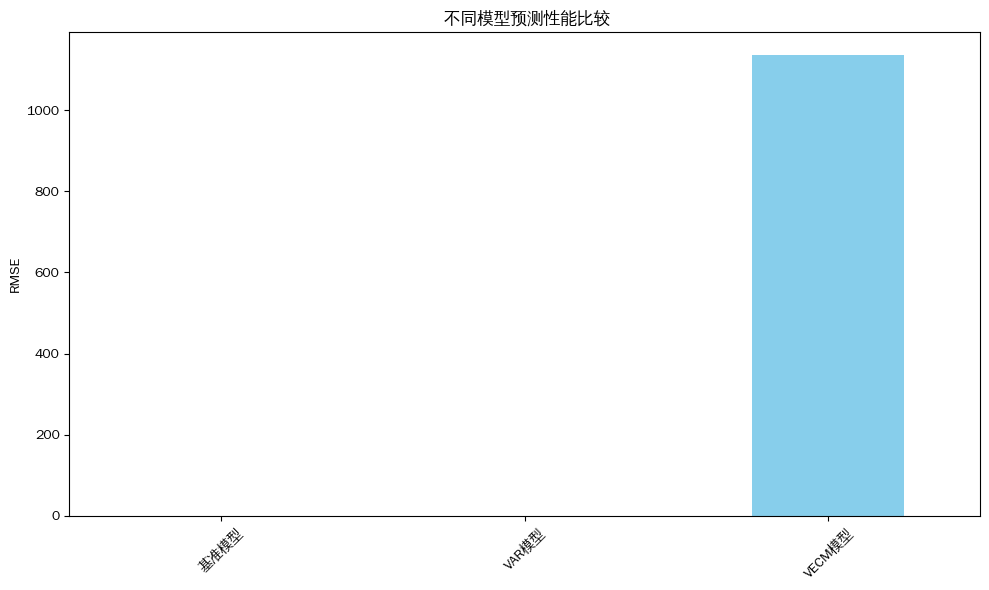

In [9]:
# 执行各种分析 
lead_lag, max_corr = analyzer.cross_correlation_analysis() 
var_model = analyzer.var_analysis() 
vecm_result = analyzer.vecm_analysis() 
dtw_results = analyzer.dtw_analysis() 
wavelet_results = analyzer.wavelet_coherence_analysis() 
performance = analyzer.forecast_comparison() 

4. 结果可视化与比较

In [10]:
def comprehensive_visualization(analyzer, price_df, returns_df):
    """综合可视化分析结果"""
    
    fig = plt.figure(figsize=(20,  16))
    
    # 1. 领先-滞后关系热图 
    ax1 = plt.subplot(2,  3, 1)
    lead_lag_df = analyzer.results['cross_correlation']['lead_lag'] 
    sns.heatmap(lead_lag_df,  annot=True, cmap='RdYlBu_r', center=0, 
                ax=ax1, fmt='.0f')
    ax1.set_title(' 板块间领先-滞后关系\n(正数表示滞后，负数表示领先)')
    
    # 2. 最大相关系数热图
    ax2 = plt.subplot(2,  3, 2)
    max_corr_df = analyzer.results['cross_correlation']['max_correlation'] 
    sns.heatmap(max_corr_df,  annot=True, cmap='RdYlBu_r', center=0, 
                ax=ax2, fmt='.3f', vmin=-1, vmax=1)
    ax2.set_title(' 板块间最大相关系数')
    
    # 3. DTW距离矩阵 
    ax3 = plt.subplot(2,  3, 3)
    dtw_df = analyzer.results['dtw']['distance_matrix'] 
    sns.heatmap(dtw_df,  annot=True, cmap='viridis_r', ax=ax3, fmt='.4f')
    ax3.set_title('DTW 距离矩阵\n(距离越小越相似)')
    
    # 4. 格兰杰因果关系网络 
    ax4 = plt.subplot(2,  3, 4)
    try:
        causality_results = analyzer.results['var']['causality'] 
        
        # 创建因果关系矩阵 
        sectors = returns_df.columns 
        causality_matrix = np.zeros((len(sectors),  len(sectors)))
        
        for i, cause in enumerate(sectors):
            for j, effect in enumerate(sectors):
                if (cause, effect) in causality_results:
                    pval = causality_results[(cause, effect)]
                    if pval < 0.05:
                        causality_matrix[j, i] = 1  # cause → effect 
        
        sns.heatmap(causality_matrix,  annot=True, cmap='YlOrRd', 
                    xticklabels=sectors, yticklabels=sectors, ax=ax4)
        ax4.set_title(' 格兰杰因果关系网络\n(1表示存在因果关系)')
    except:
        ax4.text(0.5,  0.5, '因果关系分析暂不可用', 
                ha='center', va='center', transform=ax4.transAxes) 
    
    # 5. 时变相关性 
    ax5 = plt.subplot(2,  3, 5)
    window = 60
    for sector in ['科技板块', '金融板块', '消费板块']:
        rolling_corr = returns_df[sector].rolling(window).corr(returns_df['大盘指数'])
        ax5.plot(rolling_corr.index,  rolling_corr, label=sector, linewidth=2)
    
    ax5.axhline(y=0,  color='red', linestyle='--', alpha=0.5)
    ax5.set_title(' 各板块与大盘的60日滚动相关性')
    ax5.legend() 
    ax5.grid(True,  alpha=0.3)
    
    # 6. 预测性能比较
    ax6 = plt.subplot(2,  3, 6)
    performance = analyzer.results.get('performance',  None)
    if performance is not None:
        performance['RMSE'].plot(kind='bar', ax=ax6, color='lightgreen')
        ax6.set_title(' 模型预测性能比较')
        ax6.set_ylabel('RMSE') 
        plt.xticks(rotation=45) 
    else:
        ax6.text(0.5,  0.5, '预测性能分析暂不可用', 
                ha='center', va='center', transform=ax6.transAxes) 
    
    plt.tight_layout() 
    plt.show() 

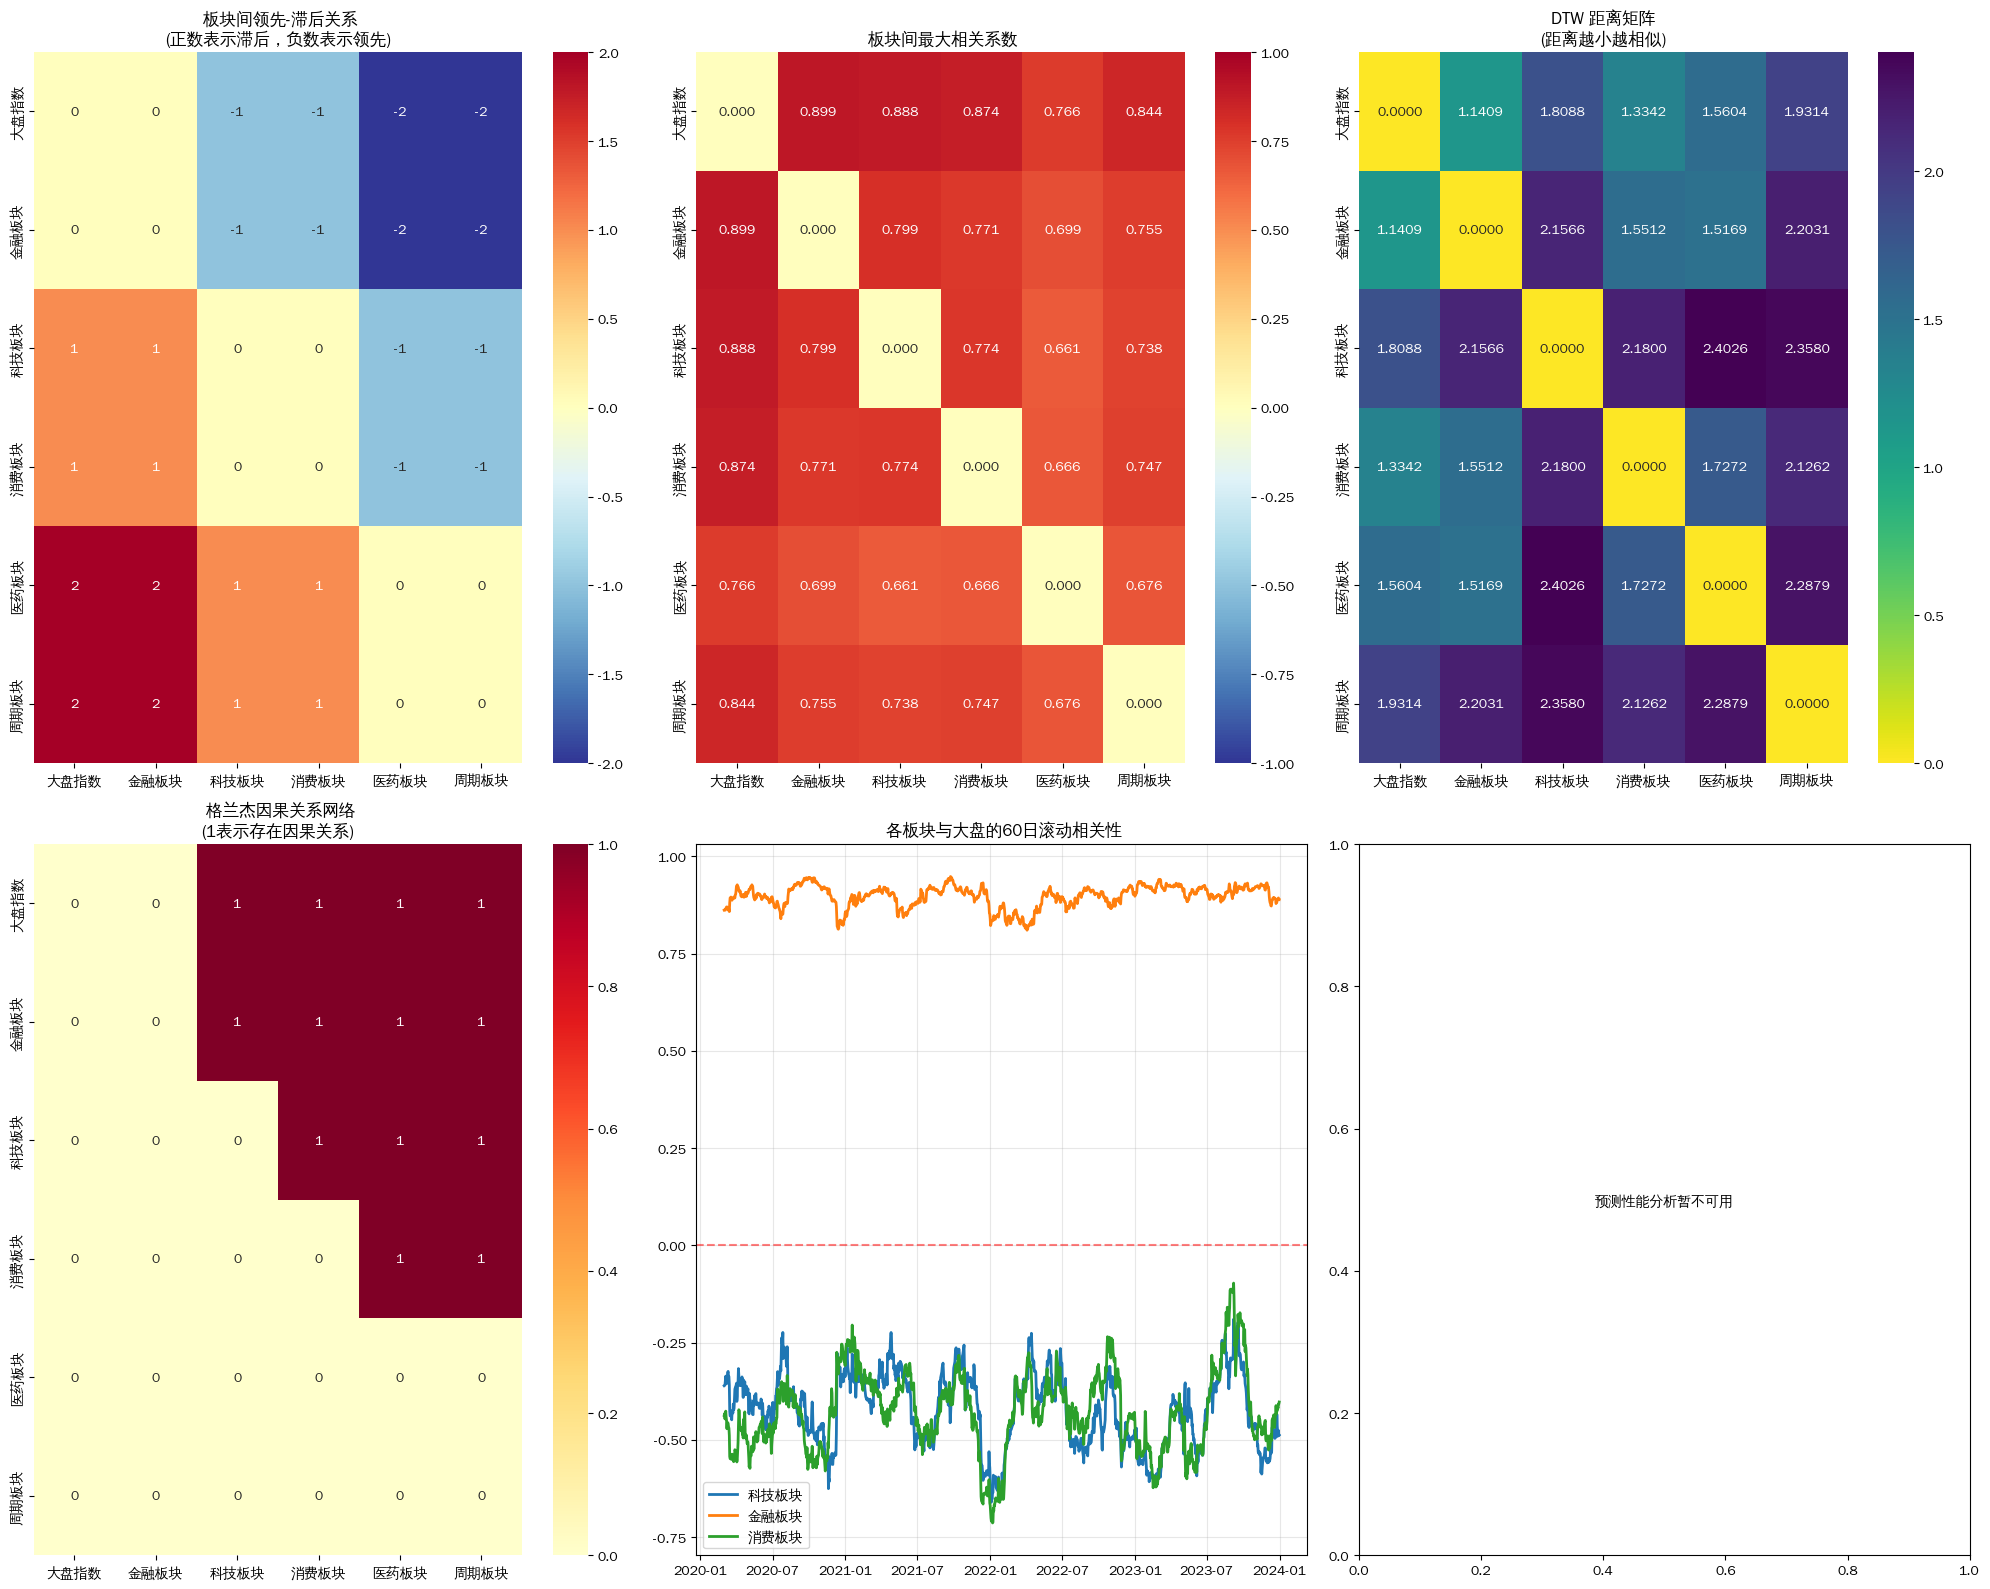

In [11]:
# 综合可视化
comprehensive_visualization(analyzer, price_df, returns_df)

#### 5. 模型优缺点总结

| 模型名称 | 优点 | 缺点 | 适用场景  | A股板块分析适用性 |
|--------|-------|------|----------|------------------|
| 交叉相关分析 |  简单直观，易于解释领先-滞后关系 |  假设线性关系，忽略动态变化 | 初步探索性分析，快速识别领先滞后  | ★★★★☆ |
| VAR模型  | 系统分析多变量动态关系，适合预测 | 参数较多，需要较大样本量 | 多变量预测，政策冲击分析 | ★★★★★ |
| VECM模型  | 处理非平稳序列，分析长期均衡关系 | 模型复杂，解释难度较大 | 长期均衡关系，协整分析 | ★★★☆☆ |
| DTW分析  | 捕捉形态相似性，不受时间缩放影响 | 计算成本高，对噪声敏感 | 形态相似性比较，模式识别 | ★★★☆☆ |
| 小波相干分析  | 分析时频域的局部相关性 | 实现复杂，需要专业软件包 | 时变特性分析，多尺度研究 | ★★☆☆☆ |


#### 6. 实战建议

| 分析目标 | 推荐方法 | 理由 |
|----------|---------|-----|
| 快速了解板块关系 | 交叉相关分析 + 滚动相关性 | 计算简单，结果直观，适合初步探索 |
| 板块轮动策略研究 | VAR模型 + 格兰杰因果检验 | 能够分析动态关系和因果关系，适合策略开发 |
| 长期配置决策 | VECM协整分析 | 分析长期均衡关系，适合资产配置 |
| 市场极端情况分析 | DTW + 小波分析 | 捕捉非线性关系和时变特性 |
| 综合研究框架 | 多模型组合使用 | 互相验证，全面分析不同维度 |